Load the graph and reference data to examine legume retrieval, protein values and preparation.

In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import xlrd
from protein_helper import DATA, FIGURES, STATES_PT, select, states
from rdflib import Graph, URIRef
from rdflib.namespace import RDFS

from taco_rdf.cli import load_graph
from taco_rdf.namespaces import (
    ALIGNMENTS_CSV,
    FOOD_NAMES_EN,
    FOODON_MODULE_TTL,
    ID,
    OBO,
    QUERIES_DIR,
    RAW_XLS,
    ROOT,
)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 60)

g = load_graph()
LEGUME = URIRef(OBO + "FOODON_00001264")
scope = pd.read_csv(DATA / "legume_foods.csv")
names_en = pd.read_csv(FOOD_NAMES_EN).set_index("food_number")
scope["name_en"] = scope["food_number"].map(names_en["name_en"])
print(f"{len(g):,} triples; {len(scope)} foods in scope")

building from current workbook, corrections and alignments


157,933 triples; 39 foods in scope


Check the selected foods against the workbook's legume group and original names.

In [2]:
sheet = xlrd.open_workbook(str(RAW_XLS)).sheet_by_index(0)
workbook, group_of, group = {}, {}, None
for i in range(3, sheet.nrows):
    row = sheet.row_values(i)
    if isinstance(row[0], str) and row[0].strip() and not any(str(c).strip() for c in row[1:]):
        group = " ".join(row[0].split())
        if group == "Legenda":
            break
    elif isinstance(row[0], float) and isinstance(row[1], str) and row[1].strip():
        workbook[int(row[0])], group_of[int(row[0])] = row, group

def same_name(a, b):
    return re.sub(r"\s+", "", a).casefold() == re.sub(r"\s+", "", b).casefold()

legume_group = {n for n, grp in group_of.items() if grp == "Leguminosas e derivados"}
assert legume_group == set(scope.loc[scope["role"] == "legume group", "food_number"])
assert all(same_name(workbook[n][1], name)
           for n, name in zip(scope["food_number"], scope["name_pt"], strict=True))
scope.groupby("role").size().rename("foods").to_frame()

,foods
role,
legume dish,5
legume group,30
legume product in another group,4


Display the foods included in the analysis.

In [3]:
scope[["food_number", "name_pt", "name_en", "role", "legume"]]

,food_number,name_pt,name_en,role,legume
0,557,"Amendoim, grão, cru","Peanut, kernel, raw",legume group,peanut
1,558,"Amendoim, torrado, salgado","Peanut, roasted, salted",legume group,peanut
2,559,"Ervilha, em vagem","Pea, in pod",legume group,pea
3,560,"Ervilha, enlatada, drenada","Pea, canned, drained",legume group,pea
4,561,"Feijão, carioca, cozido","Bean, carioca, cooked",legume group,common bean
5,562,"Feijão, carioca, cru","Bean, carioca, raw",legume group,common bean
6,563,"Feijão, fradinho, cozido","Bean, black-eyed pea (fradinho), cooked",legume group,cowpea
7,564,"Feijão, fradinho, cru","Bean, black-eyed pea (fradinho), raw",legume group,cowpea
8,565,"Feijão, jalo, cozido","Bean, jalo (yellow), cooked",legume group,common bean
9,566,"Feijão, jalo, cru","Bean, jalo (yellow), raw",legume group,common bean


Check whether selected Brazilian legume foods are absent from the workbook names.

In [4]:
names = {n: " ".join(row[1].split()).lower() for n, row in workbook.items()}
ABSENT = {
    "fava (lima bean)": lambda s: re.search(r"\bfava\b", s),
    "feijão-verde (fresh cowpea)": lambda s: "feijão" in s and "verde" in s,
    "feijão branco (white bean)": lambda s: "feijão" in s and "branco" in s,
    "feijão mulatinho": lambda s: "mulatinho" in s,
    "soybean grain": lambda s: s.startswith("soja") and ("grão" in s or "cru" in s),
    "chickpea, cooked": lambda s: "grão-de-bico" in s and "cozid" in s,
}
absent = pd.DataFrame([(food, sum(bool(test(s)) for s in names.values())) for food, test in ABSENT.items()],
                      columns=["legume food", "names in TACO"])
assert (absent["names in TACO"] == 0).all()
absent

,legume food,names in TACO
0,fava (lima bean),0
1,feijão-verde (fresh cowpea),0
2,feijão branco (white bean),0
3,feijão mulatinho,0
4,soybean grain,0
5,"chickpea, cooked",0


Retrieve foods classified as legume food products through the FoodOn hierarchy.

In [5]:
found = select(g, "foods_in_foodon_class", folder=QUERIES_DIR, **{"class": f"<{LEGUME}>"})
graph_answer = set(found["food_number"])
print(f"retrieved by the graph: {len(graph_answer)} foods")

retrieved by the graph: 21 foods


Compare graph retrieval with the alignment file, ontology module and published FoodOn ancestry.

In [6]:
module = Graph().parse(FOODON_MODULE_TTL)

def under_legume(iri):
    return LEGUME in set(module.transitive_objects(URIRef(iri), RDFS.subClassOf))

links = pd.read_csv(ALIGNMENTS_CSV, dtype=str, keep_default_na=False)
links = links[links["source_type"] == "food"].assign(food_number=lambda d: d["source_key"].astype(int))
links["under_legume"] = links["target_iri"].map(under_legume)
source_answer = set(links.loc[(links["predicate"] == "type") & links["under_legume"], "food_number"])
assert graph_answer == source_answer

published = pd.read_csv(DATA / "foodon_ancestors.csv")
for cls, flag in zip(published["class"], published["legume_food_product"], strict=True):
    assert under_legume(OBO + cls) == (flag == "yes"), cls
outside = graph_answer - set(scope["food_number"])
assert not outside, outside
print(f"graph and sources agree on {len(source_answer)} foods; the module agrees with FoodOn as published "
      f"({published['foodon_release'].iloc[0].rsplit('/', 2)[-2]}) on {len(published)} classes; "
      f"no retrieved food is outside the scope")

graph and sources agree on 21 foods; the module agrees with FoodOn as published (2026-09-20) on 28 classes; no retrieved food is outside the scope


Explain why each selected food is retrieved or omitted.

In [7]:
scope = scope.merge(links[["food_number", "predicate", "target_label", "under_legume", "note"]],
                    on="food_number", how="left")
scope["retrieved"] = scope["food_number"].isin(graph_answer)
scope["under_legume"] = scope["under_legume"].astype("boolean")

def reason(row):
    if row["retrieved"]:
        return "retrieved"
    if pd.isna(row["predicate"]):
        return "no FoodOn link"
    if row["predicate"] != "type":
        return "SKOS mapping only" + (", to a legume food product" if bool(row["under_legume"]) else "")
    return "typed with a class outside legume food product"

scope["q1"] = scope.apply(reason, axis=1)
scope.groupby(["q1", "role"]).size().unstack(fill_value=0)

role,legume dish,legume group,legume product in another group
q1,,,
"SKOS mapping only, to a legume food product",0,2,2
no FoodOn link,5,4,0
retrieved,0,20,1
typed with a class outside legume food product,0,4,1


Display omitted foods alongside their alignment notes.

In [8]:
left_out = scope[~scope["retrieved"]]
left_out[["food_number", "name_en", "predicate", "target_label", "q1", "note"]].fillna("")

,food_number,name_en,predicate,target_label,q1,note
2,559,"Pea, in pod",type,06200 - garden peas (with pods) (efsa foodex2),typed with a class outside legume food product,
3,560,"Pea, canned, drained",,,no FoodOn link,
6,563,"Bean, black-eyed pea (fradinho), cooked",,,no FoodOn link,
14,571,"Bean, rosinha (pink), cooked",relatedMatch,"pink bean (cooked, canned)","SKOS mapping only, to a legume food product",TACO does not state the bean was canned
20,577,"Lentil, cooked",relatedMatch,brown lentil (cooked),"SKOS mapping only, to a legume food product",TACO does not state the lentil variety; brown is assumed...
23,580,Pé-de-moleque (peanut brittle),type,peanut brittle,typed with a class outside legume food product,
24,581,"Soy, flour",type,soybean flour,typed with a class outside legume food product,
25,582,"Soy, drink (extrato solúvel), plain, liquid",type,soybean milk,typed with a class outside legume food product,
26,583,"Soy, drink (extrato solúvel), powder",,,no FoodOn link,
29,586,"Lupin (tremoço), pickled",,,no FoodOn link,


Verify missing links and class placements outside the legume hierarchy.

In [9]:
no_link = set(scope.loc[scope["q1"] == "no FoodOn link", "food_number"])
assert no_link == set(scope.loc[scope["role"] == "legume dish", "food_number"]) | {560, 563, 583, 586}
WHOLE_PLANT = URIRef(OBO + "PO_0000003")
for n in (125, 162):
    target = links.loc[links["food_number"] == n, "target_iri"].iloc[0]
    assert WHOLE_PLANT in set(module.transitive_objects(URIRef(target), RDFS.subClassOf)), n
for label in ["soybean flour", "soybean milk", "soybean oil", "peanut brittle"]:
    row = scope[scope["target_label"] == label].iloc[0]
    assert row["predicate"] == "type" and not row["under_legume"], label
assert scope.loc[scope["food_number"] == 559, "target_label"].iloc[0].endswith("(efsa foodex2)")

Check protein values and statuses against the workbook and independent CSV transcription.

In [10]:
protein = select(g, "food_protein")
scope = scope.merge(protein[["food_number", "protein_status", "protein", "moisture"]], on="food_number")

STATUS = {"Tr": "Trace", "NA": "NotApplicable", "*": "UnderReevaluation"}
api = pd.read_csv(ROOT / "data" / "raw" / "nutrients.csv", dtype=str, keep_default_na=False)
api = api.set_index("foodId")
for n, status, value in zip(scope["food_number"], scope["protein_status"], scope["protein"], strict=True):
    cell = workbook[n][5]
    if isinstance(cell, float):
        assert status == "Measured" and abs(value - cell) <= 1e-6, n
        printed = api.loc[str(n), "protein"]
        decimals = len(printed.split(".")[1]) if "." in printed else 0
        assert abs(value - float(printed)) <= 0.5 * 10 ** -decimals + 1e-9, n
    else:
        assert status == STATUS[cell.strip()] and pd.isna(value), n
print("protein status and value agree with the workbook and with the taco-api transcription for all "
      f"{len(scope)} foods")

protein status and value agree with the workbook and with the taco-api transcription for all 39 foods


List protein values by preparation and calculate their concentrations on a dry basis.

In [11]:
def form(row):
    if row["role"] == "legume dish":
        return "dish"
    found = states(row["name_pt"], STATES_PT)
    return ", ".join(sorted(found)) if found else "not stated"

scope["form"] = scope.apply(form, axis=1)
scope["protein_dry_basis"] = scope["protein"] / (100 - scope["moisture"]) * 100
numeric = scope["protein_status"] == "Measured"
print(f"numeric protein: {numeric.sum()} of {len(scope)}; not numeric: "
      + "; ".join(f"{r.name_en} ({r.protein_status})" for r in scope[~numeric].itertuples()))
table = scope[["food_number", "name_en", "form", "protein", "moisture", "protein_dry_basis", "retrieved"]]
table.sort_values(["form", "food_number"]).round(1)

numeric protein: 38 of 39; not numeric: Oil, soybean (NotApplicable)


,food_number,name_en,form,protein,moisture,protein_dry_basis,retrieved
3,560,"Pea, canned, drained",canned,4.6,80.1,23.2,False
29,586,"Lupin (tremoço), pickled",canned,11.1,67.7,34.4,False
4,561,"Bean, carioca, cooked",cooked,4.8,80.4,24.3,True
6,563,"Bean, black-eyed pea (fradinho), cooked",cooked,5.1,80.0,25.5,False
8,565,"Bean, jalo (yellow), cooked",cooked,6.1,75.8,25.4,True
10,567,"Bean, black, cooked",cooked,4.5,80.2,22.6,True
12,569,"Bean, rajado (speckled), cooked",cooked,5.5,77.9,25.0,True
14,571,"Bean, rosinha (pink), cooked",cooked,4.5,82.6,26.1,False
16,573,"Bean, roxo (red), cooked",cooked,5.7,80.0,28.6,True
20,577,"Lentil, cooked",cooked,6.3,76.3,26.6,False


Compare raw and cooked legume pairs per 100 g and on a dry basis.

In [12]:
scope["base"] = scope["name_pt"].str.replace(r",\s*(cru|crua|cozido|cozida)$", "", regex=True)
raw = scope[scope["form"] == "raw"].set_index("base")
cooked = scope[scope["form"] == "cooked"].set_index("base")
pairs = raw.join(cooked, lsuffix="_raw", rsuffix="_cooked", how="inner")
pairs = pairs[["name_en_raw", "protein_raw", "protein_cooked", "moisture_raw", "moisture_cooked",
               "protein_dry_basis_raw", "protein_dry_basis_cooked", "retrieved_raw", "retrieved_cooked"]]
ratio = pairs["protein_cooked"] / pairs["protein_raw"]
gap = pairs["protein_dry_basis_cooked"] - pairs["protein_dry_basis_raw"]
assert ratio.between(0.2, 0.34).all()
print(f"{len(pairs)} raw and cooked pairs. Per 100 g, cooked has {ratio.min():.2f} to {ratio.max():.2f} "
      f"times the protein of raw. On a dry basis, cooked minus raw is {gap.min():.1f} to {gap.max():.1f} g "
      f"(median {gap.median():.1f} g).")
pairs.round(1)

8 raw and cooked pairs. Per 100 g, cooked has 0.21 to 0.32 times the protein of raw. On a dry basis, cooked minus raw is -2.4 to 4.7 g (median 2.2 g).


,name_en_raw,protein_raw,protein_cooked,moisture_raw,moisture_cooked,protein_dry_basis_raw,protein_dry_basis_cooked,retrieved_raw,retrieved_cooked
base,,,,,,,,,
"Feijão, carioca","Bean, carioca, raw",20.0,4.8,14.0,80.4,23.2,24.3,True,True
"Feijão, fradinho","Bean, black-eyed pea (fradinho), raw",20.2,5.1,12.7,80.0,23.1,25.5,True,False
"Feijão, jalo","Bean, jalo (yellow), raw",20.1,6.1,13.5,75.8,23.3,25.4,True,True
"Feijão, preto","Bean, black, raw",21.3,4.5,14.9,80.2,25.1,22.6,True,True
"Feijão, rajado","Bean, rajado (speckled), raw",17.3,5.5,15.0,77.9,20.3,25.0,True,True
"Feijão, rosinha","Bean, rosinha (pink), raw",20.9,4.5,12.0,82.6,23.8,26.1,True,False
"Feijão, roxo","Bean, roxo (red), raw",22.2,5.7,12.6,80.0,25.4,28.6,True,True
Lentilha,"Lentil, raw",23.2,6.3,11.5,76.3,26.2,26.6,True,False


Plot raw and cooked protein values alongside their retrieval status.

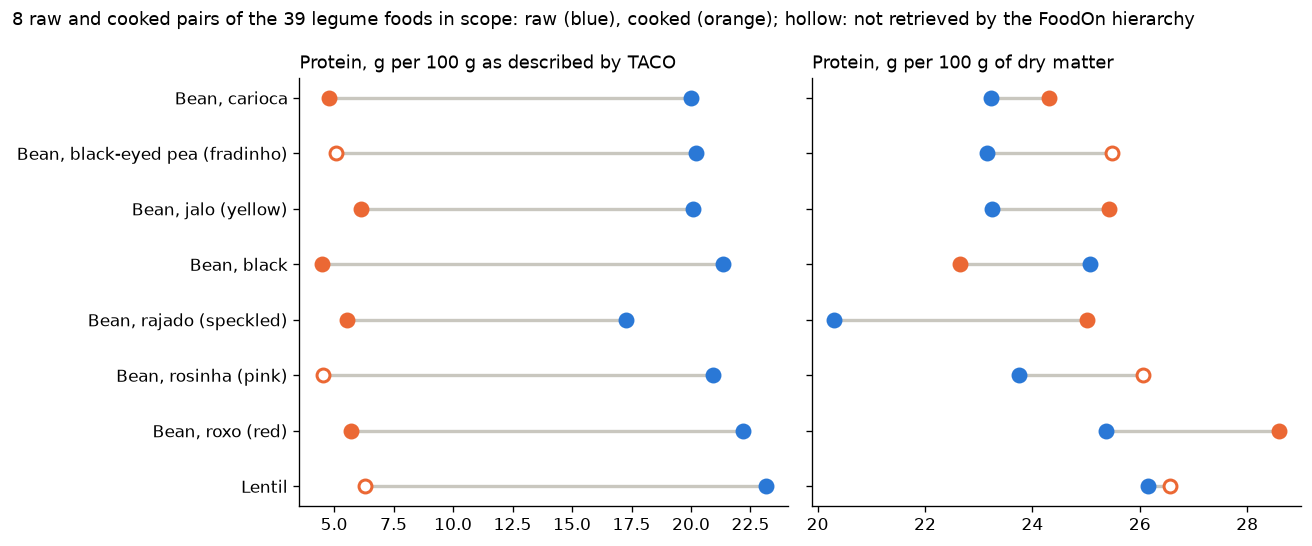

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), dpi=120, sharey=True)
for ax, column, title in [(axes[0], "protein", "Protein, g per 100 g as described by TACO"),
                          (axes[1], "protein_dry_basis", "Protein, g per 100 g of dry matter")]:
    for i, (_, row) in enumerate(pairs.iterrows()):
        values = [row[f"{column}_raw"], row[f"{column}_cooked"]]
        ax.plot(values, [i, i], color="#c9c7bf", linewidth=2, zorder=1)
        for value, state, colour in zip(values, ("raw", "cooked"), ("#2a78d6", "#eb6834"), strict=True):
            kept = row[f"retrieved_{state}"]
            ax.scatter(value, i, s=60, zorder=2, color=colour if kept else "white", edgecolors=colour,
                       linewidths=1.8)
    ax.set_title(title, loc="left", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_yticks(range(len(pairs)), [n.rsplit(",", 1)[0] for n in pairs["name_en_raw"]])
axes[0].invert_yaxis()
fig.suptitle(f"{len(pairs)} raw and cooked pairs of the {len(scope)} legume foods in scope: raw (blue), "
             f"cooked (orange); hollow: not retrieved by the FoodOn hierarchy",
             x=0.01, ha="left", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "legume_protein_raw_cooked.svg", bbox_inches="tight", metadata={"Date": None})
plt.show()

Compare retrieval rates for raw and cooked foods.

In [14]:
stated = scope[scope["form"].isin(["raw", "cooked"])]
lean = pd.crosstab(stated["form"], stated["retrieved"].map({True: "retrieved", False: "left out"}))
lean.columns.name = None
lean["share retrieved"] = (lean["retrieved"] / lean.sum(axis=1)).round(2)
assert lean.loc["raw", "share retrieved"] > lean.loc["cooked", "share retrieved"]
retrieved = scope[scope["retrieved"] & (scope["protein_status"] == "Measured")]
print(f"mean protein of everything retrieved: {retrieved['protein'].mean():.1f} g per 100 g, a figure that "
      f"mixes forms; by form: " + "; ".join(f"{k} {v:.1f} g" for k, v in
                                           retrieved.groupby('form')['protein'].mean().items()))
lean

mean protein of everything retrieved: 16.2 g per 100 g, a figure that mixes forms; by form: cooked 5.3 g; not stated 8.6 g; raw 22.2 g; roasted, salted 22.5 g


,left out,retrieved,share retrieved
form,,,
cooked,3,5,0.62
raw,2,12,0.86


Identify FoodOn classes shared by multiple foods in scope.

In [15]:
typed = scope[scope["predicate"] == "type"].assign(under_legume=lambda d: d["under_legume"].astype(bool))
shared = typed.groupby("target_label").filter(lambda d: len(d) > 1)
assert set(shared["target_label"]) == {"pinto bean (raw)", "pinto bean (cooked)"}
shared[["target_label", "food_number", "name_en", "protein"]].round(1)

,target_label,food_number,name_en,protein
4,pinto bean (cooked),561,"Bean, carioca, cooked",4.8
5,pinto bean (raw),562,"Bean, carioca, raw",20.0
12,pinto bean (cooked),569,"Bean, rajado (speckled), cooked",5.5
13,pinto bean (raw),570,"Bean, rajado (speckled), raw",17.3


Count agency classes used as food types and check their placement outside the food product hierarchy.

In [16]:
AGENCY = r"\((?:efsa foodex2|gs1 gpc|eurofir|codex|us cfr)\)"
FOOD_PRODUCT = URIRef(OBO + "FOODON_00001002")
all_types = links[links["predicate"] == "type"]
agency = all_types[all_types["target_label"].str.contains(AGENCY, regex=True)]
assert not any(FOOD_PRODUCT in set(module.transitive_objects(URIRef(t), RDFS.subClassOf))
               for t in agency["target_iri"])
print(f"{len(agency)} of {len(all_types)} food types use an agency class; in the FoodOn module none of "
      f"these classes is under food product (FOODON_00001002)")
agency[["food_number", "target_label"]]

21 of 311 food types use an agency class; in the FoodOn module none of these classes is under food product (FOODON_00001002)


,food_number,target_label
162,24,03370 - mixed breakfast cereals (efsa foodex2)
169,32,"00810 - rye flour, wholemeal (efsa foodex2)"
172,35,00880 - wheat flour (efsa foodex2)
178,41,01790 - fresh egg pasta (efsa foodex2)
182,45,09520 - sweet corn canned (efsa foodex2)
210,484,38750 - cheese omelette (efsa foodex2)
236,470,33240 - isotonic and sport drinks (efsa foodex2)
239,474,33310 - beer and beer-like beverage (efsa foodex2)
263,465,processed cheese (eurofir)
278,506,30670 - quince cheese (efsa foodex2)


Compare class placements for related legume products.

In [17]:
placement = typed.groupby("legume").agg(
    under_legume=("under_legume", lambda s: ", ".join(typed.loc[s[s].index, "target_label"])),
    elsewhere=("under_legume", lambda s: ", ".join(typed.loc[s[~s].index, "target_label"])))
placement[placement["elsewhere"] != ""]

,under_legume,elsewhere
legume,,
pea,,06200 - garden peas (with pods) (efsa foodex2)
peanut,"peanut (raw), peanut (skin off, salted, roasted), peanut...",peanut brittle
soybean,"tofu, soy sauce food product","soybean flour, soybean milk, soybean oil"


Count selected foods with amino acid values in the workbook.

In [18]:
amino_sheet = xlrd.open_workbook(str(RAW_XLS)).sheet_by_index(2)
listed = {int(row[0]) for row in (amino_sheet.row_values(i) for i in range(3, amino_sheet.nrows))
          if isinstance(row[0], float) and isinstance(row[1], str) and row[1].strip()}
with_amino_acids = scope[scope["food_number"].isin(listed)]
print(f"amino acids given for {len(with_amino_acids)} of {len(scope)} foods in scope: "
      + ", ".join(with_amino_acids["name_en"]))

amino acids given for 1 of 39 foods in scope: Pé-de-moleque (peanut brittle)

Inspect all recorded properties of the protein measurement for raw carioca beans.

In [19]:
measurement = ID["measurement/562/protein"]
facts = pd.DataFrame([(g.namespace_manager.normalizeUri(p), g.namespace_manager.normalizeUri(o)
                       if isinstance(o, URIRef) else str(o)) for p, o in g.predicate_objects(measurement)],
                     columns=["property", "value"]).sort_values("property")
facts

,property,value
5,qudt:numericValue,19.981884
6,qudt:unit,unit:GM
0,rdf:type,taco:NutrientMeasurement
1,taco:ofFood,<https://w3id.org/taco-rdf/id/food/562>
2,taco:ofNutrient,<https://w3id.org/taco-rdf/id/nutrient/protein>
4,taco:referenceBasis,<https://w3id.org/taco-rdf/id/reference/edible-portion-1...
3,taco:valueStatus,taco:Measured


Check alignment review statuses and count draft English names.

In [20]:
TACO = "https://w3id.org/taco-rdf/vocab#"
unreviewed = {int(str(f).rsplit("/", 1)[1]) for f, record in g.subject_objects(URIRef(TACO + "alignment"))
              if str(f).startswith(str(ID) + "food/")
              and (record, URIRef(TACO + "reviewStatus"), URIRef(TACO + "Unreviewed")) in g}
linked = set(scope.loc[scope["predicate"].notna(), "food_number"])
assert linked <= unreviewed
draft = names_en.loc[scope["food_number"], "status"].eq("draft").sum()
print(f"{len(linked)} linked foods in scope, all with review status Unreviewed; "
      f"{draft} of {len(scope)} English names are drafts")

30 linked foods in scope, all with review status Unreviewed; 39 of 39 English names are drafts

Summarize retrieval, protein availability and limitations supported by the checks.

In [21]:
counts = scope["q1"].value_counts()
print(f"1. The FoodOn hierarchy retrieves {len(graph_answer)} of the {len(scope)} legume foods in scope. "
      f"Left out: " + "; ".join(f"{v} {k}" for k, v in counts.items() if k != "retrieved") + ".")
raw_n, cooked_n = (scope["form"] == "raw").sum(), (scope["form"] == "cooked").sum()
print(f"2. {numeric.sum()} of {len(scope)} have a numeric protein value per 100 g ({raw_n} raw, "
      f"{cooked_n} cooked, the rest products, preserved or dishes); soybean oil is NA. Per 100 g, raw and "
      f"cooked values differ; dry matter normalization describes these differences without establishing their cause.")
print(f"3. Limits: the hierarchy retrieves raw foods more often than cooked ones; carioca and rajado share "
      f"one class; {len(agency)} food types use agency classes outside FoodOn's food product classes; "
      f"related soy and peanut foods are placed differently by FoodOn; amino acids exist for "
      f"{len(with_amino_acids)} "
      f"food; methods are not recorded; the links are unreviewed; the FoodOn release matters.")
print("The checks show that the graph, the workbook, the taco-api transcription, the alignment file and "
      "FoodOn agree with each other; they do not show that each FoodOn class is right for its food, "
      "which only a review can say.")

1. The FoodOn hierarchy retrieves 21 of the 39 legume foods in scope. Left out: 9 no FoodOn link; 5 typed with a class outside legume food product; 4 SKOS mapping only, to a legume food product.
2. 38 of 39 have a numeric protein value per 100 g (14 raw, 8 cooked, the rest products, preserved or dishes); soybean oil is NA. Per 100 g, raw and cooked values differ; dry matter normalization describes these differences without establishing their cause.
3. Limits: the hierarchy retrieves raw foods more often than cooked ones; carioca and rajado share one class; 21 food types use agency classes outside FoodOn's food product classes; related soy and peanut foods are placed differently by FoodOn; amino acids exist for 1 food; methods are not recorded; the links are unreviewed; the FoodOn release matters.
The checks show that the graph, the workbook, the taco-api transcription, the alignment file and FoodOn agree with each other; they do not show that each FoodOn class is right for its food, wh